In [1]:
# Import pandas for handling the dataset
import pandas as pd

# Import matplotlib for charts
import matplotlib.pyplot as plt

# Split dataset into training/testing
from sklearn.model_selection import train_test_split

# Import SVM model
from sklearn.svm import SVC

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
# Load the dataset from CSV file
df = pd.read_csv("dataset.csv")

# Display first 5 rows
df.head()

,fever,headache,cough,fatigue,body pain,sore throat,chest pain,shortness of breath,vomiting,diarrhea,...,ear pain,eye redness,blurred vision,palpitations,anxiety,loss of appetite,weight loss,swelling,dry mouth,disease
0,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
1,1,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
2,1,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
3,1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
4,1,0,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu


In [3]:
# Show dataset size
print("Dataset shape:", df.shape)

# Show number of samples per disease
print("\nDisease counts:")
print(df["disease"].value_counts())

Dataset shape: (360, 31)

Disease counts:
disease
Flu                        20
Common Cold                20
COVID-19                   20
Migraine                   20
Food Poisoning             20
Gastritis                  20
Respiratory Issue          20
Allergy                    20
Urinary Tract Infection    20
Joint Inflammation         20
Asthma                     20
Bronchitis                 20
Pneumonia                  20
Eczema                     20
Skin Infection             20
Vertigo                    20
Possible Cardiac Issue     20
Kidney Stone               20
Name: count, dtype: int64


In [4]:
# X contains symptom features
X = df.drop("disease", axis=1)

# y contains disease labels
y = df["disease"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (360, 30)
Target shape: (360,)


In [5]:
# Split dataset:
# 80% training
# 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (288, 30)
Testing size: (72, 30)


In [6]:
# Create SVM model
# kernel='rbf' allows the model to learn non-linear patterns
# class_weight='balanced' helps treat all diseases fairly
# probability=True allows probability/confidence estimation

svm_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=True,
    random_state=42
)

# Train the model using training data
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [7]:
# Predict diseases using the testing data
y_pred = svm_model.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [8]:
# Calculate model performance
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("SVM Results")
print("-----------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

SVM Results
-----------
Accuracy: 0.625
Precision: 0.619
Recall: 0.625
F1-score: 0.6051


In [9]:
# Detailed performance for each disease class
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

                         precision    recall  f1-score   support

                Allergy       0.75      0.75      0.75         4
                 Asthma       0.00      0.00      0.00         4
             Bronchitis       0.00      0.00      0.00         4
               COVID-19       0.00      0.00      0.00         4
            Common Cold       1.00      0.50      0.67         4
                 Eczema       1.00      1.00      1.00         4
                    Flu       0.60      0.75      0.67         4
         Food Poisoning       1.00      0.75      0.86         4
              Gastritis       0.80      1.00      0.89         4
     Joint Inflammation       1.00      1.00      1.00         4
           Kidney Stone       0.67      1.00      0.80         4
               Migraine       0.80      1.00      0.89         4
              Pneumonia       0.33      0.25      0.29         4
 Possible Cardiac Issue       0.50      0.75      0.60         4
      Respiratory Issue 

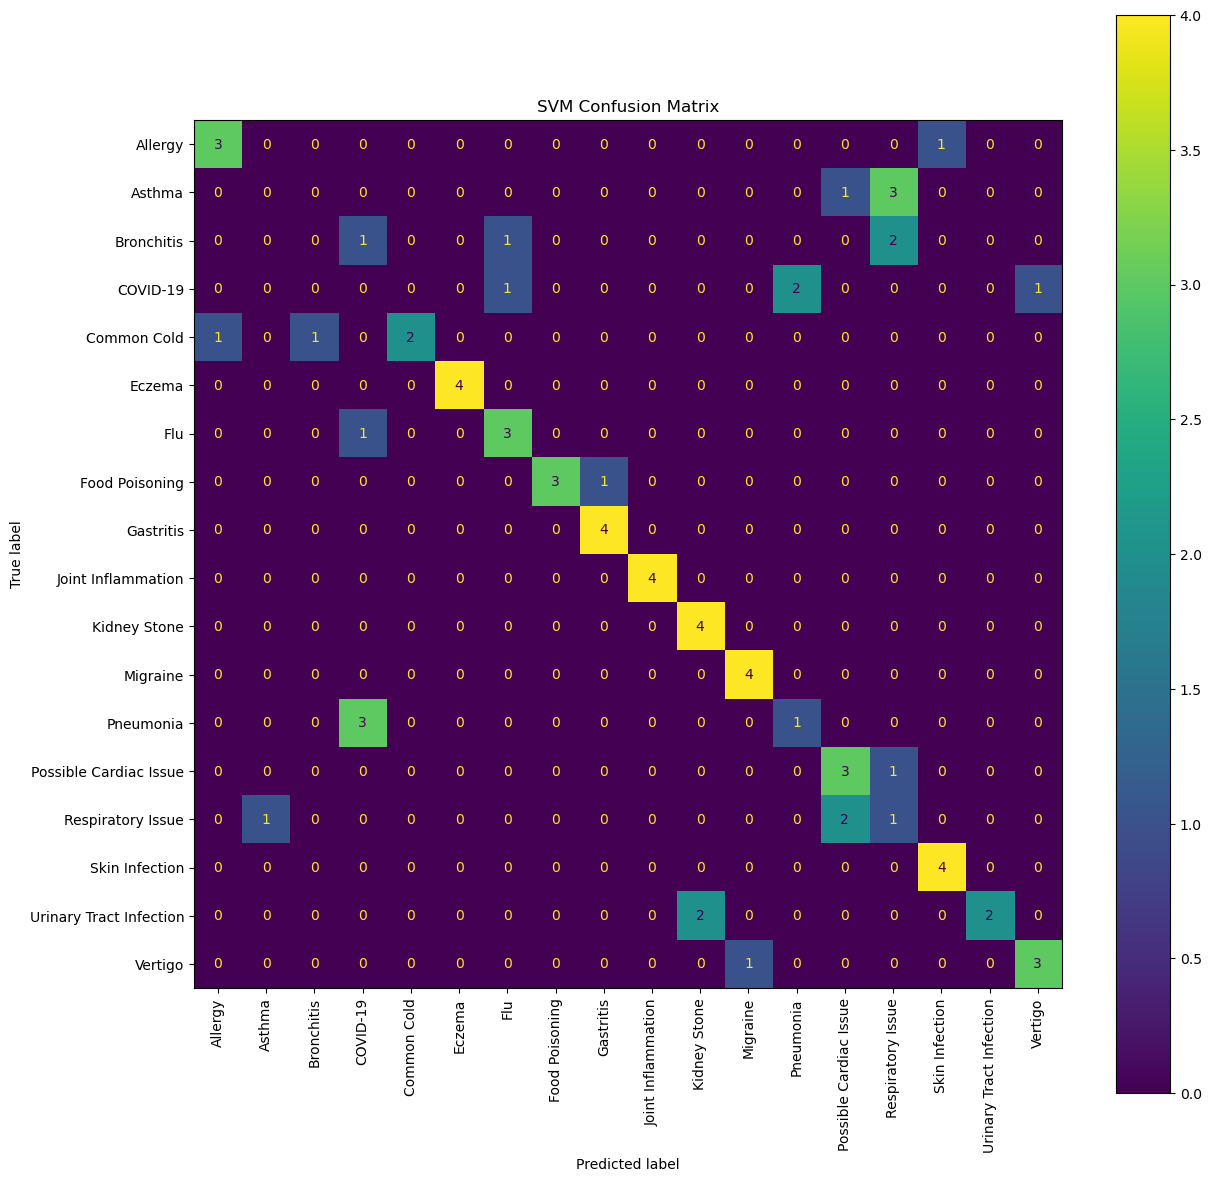

In [10]:
# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=svm_model.classes_
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

fig, ax = plt.subplots(figsize=(14, 14))

disp.plot(ax=ax, xticks_rotation=90)

plt.title("SVM Confusion Matrix")
plt.show()

In [11]:
# Store SVM results for final model comparison

svm_results = {
    "Model": "SVM",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1-score": round(f1, 4)
}

svm_results

{'Model': 'SVM',
 'Accuracy': 0.625,
 'Precision': 0.619,
 'Recall': 0.625,
 'F1-score': 0.6051}